Dataset shape: (150, 5)

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Species distribution:
 Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

=== DESCRIPTIVE STATISTICS ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min         

/tmp/ipython-input-1845791746.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("\nBy Species:\n", df.groupby('Species').describe())


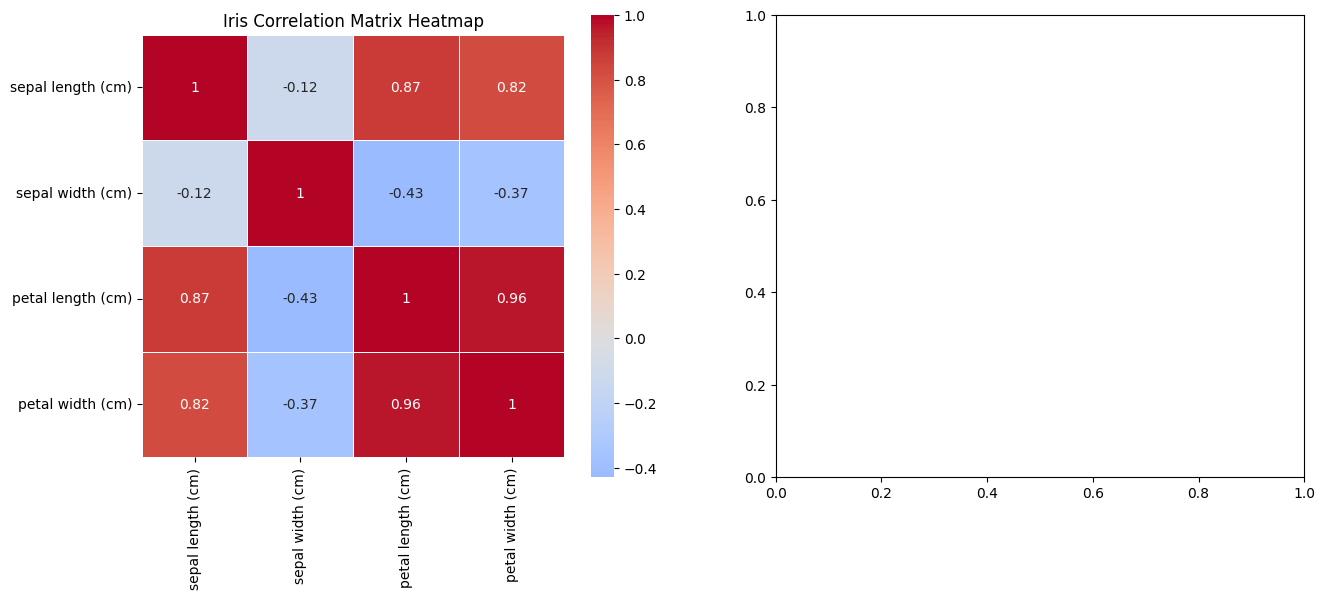

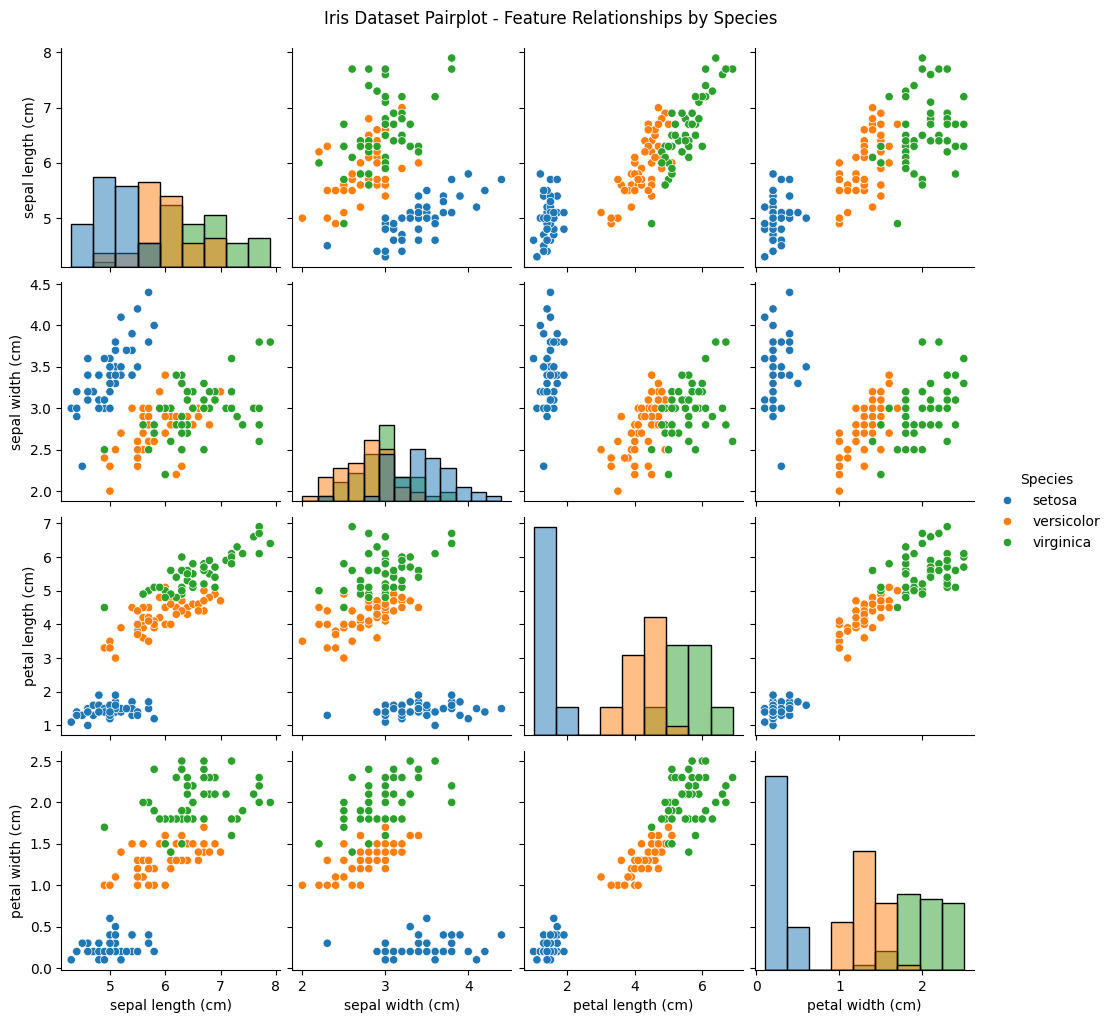

<Figure size 640x480 with 0 Axes>


Strongest correlations (|r| > 0.7):
            Feature1           Feature2  Correlation
1  sepal length (cm)  petal length (cm)        0.872
2  sepal length (cm)   petal width (cm)        0.818
4  petal length (cm)  sepal length (cm)        0.872
6  petal length (cm)   petal width (cm)        0.963
7   petal width (cm)  sepal length (cm)        0.818
8   petal width (cm)  petal length (cm)        0.963


In [3]:
# Data Science Lab Assignment 2: Descriptive Statistics & Correlation Analysis
# Dataset: Iris Species (Kaggle/UCI) [web:120]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Step 1: Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nSpecies distribution:\n", df['Species'].value_counts())

# Step 2: DESCRIPTIVE STATISTICS
print("\n=== DESCRIPTIVE STATISTICS ===")
print(df.describe())
print("\nBy Species:\n", df.groupby('Species').describe())

# Step 3a: CORRELATION MATRIX
corr_matrix = df.iloc[:, :-1].corr()  # Numeric features only
print("\n=== CORRELATION MATRIX ===")
print(corr_matrix.round(3))

# Step 3b: CORRELATION VISUALIZATIONS
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Iris Correlation Matrix Heatmap')

# Pairplot (overview of all relationships)
sns.pairplot(df, hue='Species', diag_kind='hist')
plt.suptitle('Iris Dataset Pairplot - Feature Relationships by Species', y=1.02)
plt.show()

plt.tight_layout()
plt.show()

# Strongest correlations
print("\nStrongest correlations (|r| > 0.7):")
strong_corr = corr_matrix[abs(corr_matrix) > 0.7].stack().reset_index()
strong_corr.columns = ['Feature1', 'Feature2', 'Correlation']
strong_corr = strong_corr[strong_corr['Feature1'] != strong_corr['Feature2']]
print(strong_corr.round(3))
